# **Week 2 Notebook**
**Lundy Zheng**

This week, we delve into the Momentum Factor and Value Factor, and use these are signals to investigate their according investment strategies.

# Task 1

Completed. Research question and checklist in journal & memo

# Task 2

For task 2, we create a function that defines the value factor. I'm seeking the function to input one of the returns tables from last week and making the function append a new column with value score as the return.

In [3]:
# We start by initializing the data from last week, importing necessary functions
import sys
sys.path.append("..")
import pandas as pd
import yfinance as yf
import requests
import time
import numpy as np
import matplotlib.pyplot as plt

from src.data_utils import load_ohlcv
from src.data_utils import validate_ohlcv
from src.data_utils import compute_returns
from src.data_utils import get_all_shares_outstanding
from src.data_utils import merge_shares_with_returns
from src.data_utils import rolling_statistics
from src.data_utils import plot_return_distribution

In [4]:
# Basics: Not all needed to run every function
#50 Tickers from S&P500 and SPY (51 total)
portfolio_tickers = [
    "NVDA", "AAPL", "GOOGL", "GOOG", "MSFT", "AMZN", "META", "AVGO", "TSLA", "MU",
    "BRK-B", "LLY", "AMD", "JPM", "WMT", "V", "XOM", "INTC", "JNJ", "MA",
    "ABBV", "ORCL", "DIS", "CSCO", "CVX", "COST", "BAC", "LRCX", "KO", "AMAT",
    "MRK", "CAT", "DELL", "PG", "UNH", "GE", "MS", "PANW", "HD", "NFLX",
    "PM", "GS", "IBM", "ANET", "WFC", "CRWD", "RTX", "VZ", "TXN", "TMUS"
]

API_KEY = "GPIZN6KZY4TLF6LJ"

benchmark_ticker = "SPY"

tickers = portfolio_tickers + [benchmark_ticker]

start_date = "2020-01-01"
end_date = "2026-06-01"

# Standard data quality check. Nothing out of the ordinary; hashed line to avoid lag due to high output quantity.
df = load_ohlcv("../data/processed/ohlcv.parquet")
df["daily_simple_return"] = (
    df.groupby("ticker")["adjusted_close"]
      .pct_change(fill_method = None)
)
#validate_ohlcv(df)

In [5]:
# Preparing data to the form we need: Daily
df, returns_df = compute_returns(df)
daily_returns = returns_df[
    returns_df["frequency"] == "daily"
].drop(columns="frequency").reset_index(drop=True).copy()
# For consistency's sake, we use simple returns from here. Results shouldn't differ greatly. This is removed for the value factor analysis so doesn't matter.
daily_returns = rolling_statistics(daily_returns, window=20, return_type= "simple_return")

# Get shares outstanding & merge
shares_df = get_all_shares_outstanding(portfolio_tickers, "2019-01-01")
daily_combined_df = merge_shares_with_returns(daily_returns, shares_df)

# Do the same for monthly as it might be easier (since research question asks a month-by-month basis
monthly_returns = returns_df[
    returns_df["frequency"] == "monthly"
].drop(columns="frequency").reset_index(drop=True).copy()
monthly_returns = rolling_statistics(monthly_returns, window=12, return_type= "simple_return") # Though here the rolling statistics would be imposed as the past 12 months. I'm not sure we want this.
monthly_combined_df = merge_shares_with_returns(monthly_returns, shares_df)

In [6]:
# I have to turn to SEC EDGAR to get full data on book equity; since I don't really know the formalisms I'm using AI to assist me mostly here.
headers = {
    "User-Agent": "Lundy Zheng research 22lundyz@gmail.com"
}

ticker_url = "https://www.sec.gov/files/company_tickers.json"

ticker_data = requests.get(
    ticker_url,
    headers=headers
).json()

ticker_df = pd.DataFrame(ticker_data).T

In [7]:
def get_cik(ticker):
    """
    Find SEC CIK for a ticker.
    """

    match = ticker_df[
        ticker_df["ticker"] == ticker
    ]

    if match.empty:
        return None

    return str(
        match.iloc[0]["cik_str"]
    ).zfill(10)

get_cik("AAPL")

def get_book_equity_sec(ticker, start_date):
    """
    Pull historical stockholders' equity from SEC EDGAR.

    Input:
        ticker: stock ticker (str)
        start_date: earliest fiscal period end to include (str)

    Output:
        dataFrame containing:
        ticker
        fiscal_date
        filed_date
        book_equity
        form
    """

    cik = get_cik(ticker)

    if cik is None:
        print(f"No CIK found for {ticker}")
        return None

    url = (
        f"https://data.sec.gov/api/xbrl/companyfacts/"
        f"CIK{cik}.json"
    )

    response = requests.get(
        url,
        headers=headers
    )

    data = response.json()

    facts = data["facts"]["us-gaap"]

    equity_concepts = [
        "StockholdersEquity",
        "StockholdersEquityIncludingPortionAttributableToNoncontrollingInterest",
        "PartnersCapital",
    ]
    
    equity_concept = None
    most_observations = 0
    
    for concept in equity_concepts:
    
        if concept in facts:
    
            units = facts[concept].get("units", {})
    
            if "USD" in units:
    
                observations = units["USD"]
    
                if len(observations) > most_observations:
                    most_observations = len(observations)
                    equity_concept = concept
    
    if equity_concept is None:
        print(f"No usable equity concept found for {ticker}")
        return None
    
    equity_data = facts[equity_concept]["units"]["USD"]
    
    # Turn the SEC equity observations into a dataframe
    df = pd.DataFrame(equity_data)
    
    # Add which SEC equity concept we used
    df["equity_concept"] = equity_concept
    
    df = df[
        df["form"].isin(["10-K", "10-Q"])
    ].copy()
    
    df["end"] = pd.to_datetime(df["end"])
    df["filed"] = pd.to_datetime(df["filed"])
    
    df = df[
        df["end"] >= pd.to_datetime(start_date)
    ]
    
    df = df.rename(columns={
        "end": "fiscal_date",
        "filed": "filed_date",
        "val": "book_equity"
    })
    
    df["ticker"] = ticker
    
    df = df[
        [
            "ticker",
            "fiscal_date",
            "filed_date",
            "book_equity",
            "form",
            "equity_concept"
        ]
    ]
    
    # Sort by fiscal period first, then by when it was filed
    df = df.sort_values(
        ["fiscal_date", "filed_date"]
    )
    
    # If the same fiscal period appears in multiple later filings,
    # keep the first time that information was reported
    df = df.drop_duplicates(
        subset=["ticker", "fiscal_date"],
        keep="first"
    )
    
    df = df.reset_index(drop=True)
    
    return df

In [8]:
def get_all_book_equity_sec(tickers, start_date):
    """
    Gets all the book equity information from the list of tickers.

    Input:
        tickers: list of all tickers used (list)
        start_date: start date of data grab (str)
    """

    all_book_equity = []

    for ticker in tickers:

        try:
            ticker_df = get_book_equity_sec(
                ticker,
                start_date
            )

            if ticker_df is not None:
                all_book_equity.append(ticker_df)
                #print(f"Completed: {ticker}")

            else:
                print(f"Skipped: {ticker}")

        except Exception as e:
        #    print(f"Error for {ticker}: {e}")

        # To not exceed data grab limit
            time.sleep(0.15)

    if len(all_book_equity) == 0:
        return pd.DataFrame()

    return pd.concat(
        all_book_equity,
        ignore_index=True
    )

book_equity_df = get_all_book_equity_sec(
    portfolio_tickers,
    start_date="2019-01-01"
)

book_equity_df.groupby("ticker").size()

ticker
AAPL     30
ABBV     30
AMAT     31
AMD      30
AMZN     30
ANET     30
AVGO     31
BAC      30
BRK-B    30
CAT      32
COST     24
CRWD     28
CSCO     31
CVX      30
DELL     31
DIS      30
GE       30
GOOG     30
GOOGL    30
GS       30
HD       31
IBM      30
INTC     30
JNJ      30
JPM      30
KO       29
LLY      27
LRCX     30
MA       30
META     30
MRK      30
MS       30
MSFT     30
MU       30
NFLX     30
NVDA     31
ORCL     31
PANW     31
PG       30
PM       30
RTX      30
TMUS     30
TSLA     30
TXN      30
UNH      30
V        29
VZ       30
WFC      30
WMT      31
XOM       6
dtype: int64

In [9]:
# Unfortunately XOM doesn't have the valid data for value factor analysis, so we will exclude it for this part.
book_equity_df = book_equity_df[
    book_equity_df["ticker"] != "XOM"
].copy()

book_equity_df = book_equity_df.reset_index(drop=True)

# Build function for merging
def build_value_df(daily_combined_df, book_equity_df):
    """
    Construct a dataframe for value-factor analysis.

    Inputs:
        daily_combined_df:
            Daily stock data containing at least:
            ticker, date, close, simple_return, log_return,
            shares_outstanding

        book_equity_df:
            SEC book equity data containing at least:
            ticker, filed_date, book_equity

    Output:
        value_df:
            DataFrame containing:
            ticker, date, close, simple_return, log_return,
            shares_outstanding, market_cap,
            filed_date, book_equity, book_to_market
    """

    # Keep only columns relevant for value-factor research
    market_df = daily_combined_df[
        [
            "ticker",
            "date",
            "close",
            "simple_return",
            "log_return",
            "shares_outstanding"
        ]
    ].copy()

    # Calculate historical market capitalization
    market_df["market_cap"] = (
        market_df["close"]
        * market_df["shares_outstanding"]
    )

    # Keep only the book-equity information we need
    book_df = book_equity_df[
        [
            "ticker",
            "filed_date",
            "book_equity"
        ]
    ].copy()

    # Make sure date columns are datetime
    market_df["date"] = pd.to_datetime(
        market_df["date"]
    )

    book_df["filed_date"] = pd.to_datetime(
        book_df["filed_date"]
    )

    # Sort before using merge_asof
    market_df = market_df.sort_values(
        ["date", "ticker"]
    ).reset_index(drop=True)
    
    book_df = book_df.sort_values(
        ["filed_date", "ticker"]
    ).reset_index(drop=True)

    # Match each market date with the latest book equity
    # that had already been publicly filed
    value_df = pd.merge_asof(
        market_df,
        book_df,
        left_on="date",
        right_on="filed_date",
        by="ticker",
        direction="backward"
    )

    # Construct book-to-market value signal
    value_df["book_to_market"] = (
        value_df["book_equity"]
        / value_df["market_cap"]
    )

    return value_df.reset_index(drop=True)

value_df = build_value_df(
    daily_combined_df,
    book_equity_df
)

value_df.head()

,ticker,date,close,simple_return,log_return,shares_outstanding,market_cap,filed_date,book_equity,book_to_market
0,AAPL,2020-01-02,75.087502,NaN,NaN,4.443270e+09,3.336341e+11,2019-10-31,9.048800e+10,0.271219
1,ABBV,2020-01-02,89.550003,NaN,NaN,1.478820e+09,1.324283e+11,2019-11-06,-8.226000e+09,-0.062117
2,AMAT,2020-01-02,62.200001,NaN,NaN,9.153040e+08,5.693191e+10,2019-12-13,8.214000e+09,0.144278
3,AMD,2020-01-02,49.099998,NaN,NaN,1.167070e+09,5.730313e+10,2019-10-30,2.176000e+09,0.037973
4,AMZN,2020-01-02,94.900497,NaN,NaN,4.957970e+08,4.705138e+10,2019-10-25,5.650800e+10,1.200985


In [10]:
# The dataset is well prepared. We need to do one more thing: rank the companies at the end of each month based on their book-to-market ratio.
# We use the last trading day, and higher B/M corresponds to higher rank.
# I figured I'd want to continue using such a ranking function so I made a general one:
def rank_month_end(
    df,
    value_column,
    ticker_column="ticker",
    date_column="date",
    simple_return_column="simple_return",
    log_return_column="log_return",
    ascending=True,
    rank_column="rank"
):
    """
    Rank stocks at the end of each month based on a specified column.

    Inputs:
        df: dataframe
        value_column: Column to rank, e.g. "book_to_market", "momentum", "market_cap" (str)
        ticker_column: Column containing ticker names
        date_column: Column containing dates
        simple_return_column: name of column to compute monthly returns
        log_return_column: name of column to compute monthly returns
        ascending: True  -> smallest value gets rank 1; False -> largest value gets rank 1
        rank_column: Name of the new ranking column

    Output:
        dataFrame containing one observation per ticker per month,with an additional ranking column.
    """

    ranked_df = df.copy()

    # -----------------------------------
    # CASE 1: dataframe contains daily data
    # -----------------------------------
    if date_column in ranked_df.columns:

        ranked_df[date_column] = pd.to_datetime(
            ranked_df[date_column]
        )

        ranked_df["month"] = (
            ranked_df[date_column].dt.to_period("M")
        )

        # Monthly simple returns
        monthly_simple = (
            ranked_df
            .groupby([ticker_column, "month"])[simple_return_column]
            .apply(lambda x: (1 + x).prod() - 1)
            .rename("monthly_simple_return")
            .reset_index()
        )

        # Monthly log returns
        monthly_log = (
            ranked_df
            .groupby([ticker_column, "month"])[log_return_column]
            .sum()
            .rename("monthly_log_return")
            .reset_index()
        )

        # Keep month-end observation
        ranked_df = (
            ranked_df
            .sort_values([ticker_column, date_column])
            .groupby([ticker_column, "month"])
            .tail(1)
            .copy()
        )

        ranked_df = ranked_df.merge(
            monthly_simple,
            on=[ticker_column, "month"],
            how="left"
        )

        ranked_df = ranked_df.merge(
            monthly_log,
            on=[ticker_column, "month"],
            how="left"
        )

    # -----------------------------------
    # CASE 2: dataframe is already monthly
    # -----------------------------------
    elif "month" in ranked_df.columns:

        # Make sure month has the same Period format
        ranked_df["month"] = pd.PeriodIndex(
            ranked_df["month"],
            freq="M"
        )

    else:
        raise ValueError(
            "DataFrame must contain either a 'date' column or a 'month' column."
        )

    # -----------------------------------
    # Rank stocks within each month
    # -----------------------------------
    ranked_df[rank_column] = (
        ranked_df
        .groupby("month")[value_column]
        .rank(
            method="first",
            ascending=ascending
        )
    )

    return ranked_df.reset_index(drop=True)


monthly_value_df = rank_month_end(
    value_df,
    value_column="book_to_market",
    ascending=True,
    rank_column="value_rank"
)

monthly_value_df.head()

,ticker,date,close,simple_return,log_return,shares_outstanding,market_cap,filed_date,book_equity,book_to_market,month,monthly_simple_return,monthly_log_return,value_rank
0,AAPL,2020-01-31,77.377502,-0.044339,-0.045352,4.375480e+09,3.385637e+11,2020-01-29,8.953100e+10,0.264444,2020-01,0.030498,0.030042,24.0
1,AAPL,2020-02-28,68.339996,-0.000585,-0.000585,4.375480e+09,2.990203e+11,2020-01-29,8.953100e+10,0.299414,2020-02,-0.114702,-0.121830,24.0
2,AAPL,2020-03-31,63.572498,-0.002041,-0.002043,4.375480e+09,2.781602e+11,2020-01-29,8.953100e+10,0.321868,2020-03,-0.069761,-0.072314,25.0
3,AAPL,2020-04-30,73.449997,0.021096,0.020877,4.375480e+09,3.213790e+11,2020-01-29,8.953100e+10,0.278584,2020-04,0.155374,0.144424,26.0
4,AAPL,2020-05-29,79.485001,-0.000974,-0.000975,4.334330e+09,3.445142e+11,2020-05-01,7.842500e+10,0.227639,2020-05,0.085094,0.081667,25.0


# Task 3

I expect this task to be a bit easier since we already defined some of the key functions in the previous task. Here we will be creating a function for the momentum factor, looking from the t-12 month to the t-1 month for highest average returns and ranking based on such.

In [11]:
# Start from daily_combined_df and add another rolling column that details t-12 to t-1
# For momentum, our analysis must start from 2021-01-01 (we'll still get more than 5 years of data), since we need to sample the first 12 months first.

def add_momentum(df, return_col="simple_return"):
    """
    Calculate 12-1 momentum for each stock.

    Momentum at month t = cumulative return over months t-12 through t-1.

    Input:
        df: dataframe, daily_combined_df and daily_returns_df both should work.
        return_col: daily simple return column; since I decided we'd use the simple return for this, I didn't code up the log return part yet.

    Output:
        monthly dataframe with momentum column
    """

    df = df.copy()

    df["date"] = pd.to_datetime(df["date"])

    # Create month identifier
    df["month"] = df["date"].dt.to_period("M")

    # Convert daily simple returns into monthly simple returns
    monthly_df = (
        df.groupby(["ticker", "month"])[return_col]
        .apply(lambda x: (1 + x).prod() - 1)
        .reset_index(name="monthly_simple_return")
    )

    monthly_df = monthly_df.sort_values(
        ["ticker", "month"]
    ).reset_index(drop=True)

    # Calculate t-12 through t-1 cumulative return
    monthly_df["momentum"] = (
        monthly_df.groupby("ticker")["monthly_simple_return"]
        .transform(
            lambda x: (1 + x.shift(1)) # Shift by 1
            .rolling(window=12, min_periods=12)
            .apply(np.prod, raw=True) - 1
        )
    )

    monthly_df = monthly_df.dropna(subset=["momentum"])
    
    return monthly_df

momentum_df = add_momentum(daily_combined_df)
monthly_momentum_df = rank_month_end(
    momentum_df,
    value_column="momentum",
    ascending=True,
    rank_column="momentum_rank"
)
monthly_momentum_df.head()

,ticker,month,monthly_simple_return,momentum,momentum_rank
0,AAPL,2021-01,-0.005502,0.782400,46.0
1,AAPL,2021-02,-0.079712,0.720133,46.0
2,AAPL,2021-03,0.007340,0.788118,41.0
3,AAPL,2021-04,0.076218,0.936323,37.0
4,AAPL,2021-05,-0.050497,0.803663,40.0


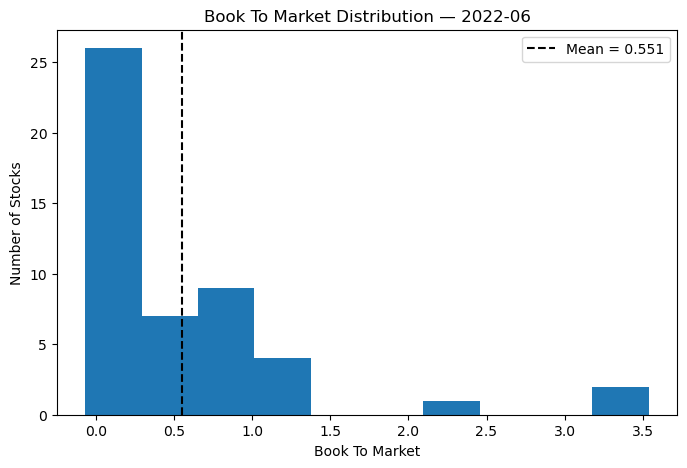

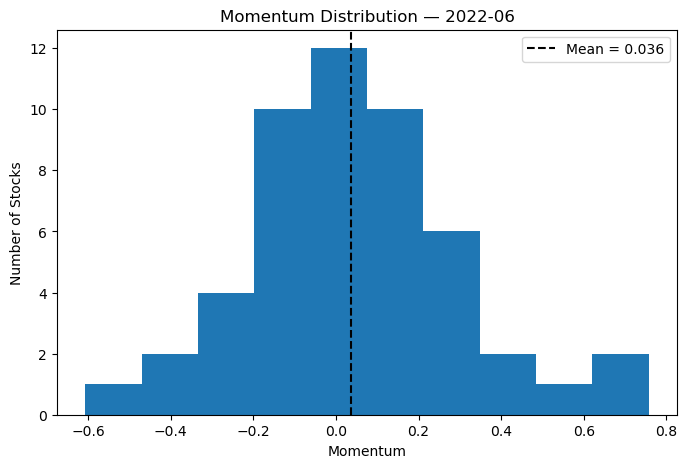

In [12]:
# Create distribution plots for both value factor and momentum factor results.
def plot_cross_sectional_distribution(
    df,
    month,
    value_column,
    bins=10
):
    """
    This function plots the cross-sectional distribution of a factor across stocks for a specified month.

    Inputs:
        df: dataframe (monthly, such as monthly_momentum_df or monthly_value_df)
        month: month to examine, e.g. "2025-12" (str)
        value_column: factor column to plot, "book_to_market" or "momentum"
        bins: number of histogram bins

    Output:
        histogram of factor values across stocks
    """

    # Select specified month
    month_data = df[
        df["month"] == month
    ][value_column].dropna()

    # Plot distribution
    plt.figure(figsize=(8, 5))

    plt.hist(
        month_data,
        bins=bins
    )

    # Add average factor value
    mean_value = month_data.mean()

    plt.axvline(
        mean_value,
        linestyle="--",
        color="black",
        label=f"Mean = {mean_value:.3f}"
    )

    plt.xlabel(
        value_column.replace("_", " ").title()
    )
    plt.ylabel("Number of Stocks")

    plt.title(
        f"{value_column.replace('_', ' ').title()} Distribution — {month}"
    )

    plt.legend()
    plt.show()

# Test on one particular month; function is generalizable.
plot_cross_sectional_distribution(monthly_value_df, "2022-06", "book_to_market", 10)

plot_cross_sectional_distribution(monthly_momentum_df, "2022-06", "momentum", 10)

# Task 4

Now we actually implement quintiles and analyze how a long-short strategy using these factors would affect a portfolio.
The idea is that at the end of every month (the rebalancing period proposed in my research question), we short Q1 and long Q3. So the net returns from the strategy is given by R_q5 - R_q1 (the difference between them)
Within each quintile we assume an equal-weight portfolio, so the returns is a simple mean of all stocks in that quintile.

In [13]:
# We've ranked each stock at the end of every month previously. We just have to separate these into five quintiles every month.
# We first add a quintile column to the main dataframe
# My idea is to then create five new dataframes for each factor, that aggregates all the stocks that each exist in Q1, Q2, Q3, Q4, Q5.
# So the required columns are: ticker, month, monthly_return, [factor], rank, quintile
# I'll create a few functions here to do each thing.

def assign_quintiles(
    df,
    factor_column,
    rank_column,
    return_column="monthly_simple_return"
):
    """
    Assign stocks to five quintiles within each month
    based on their existing factor rank.
    Here: rank 1 = strongest factor

    Inputs:
        df: monthly factor dataframe
        factor_column: e.g. "momentum" or "book_to_market"
        rank_column: e.g. "momentum_rank" or "value_rank"
        return_column: monthly return column

    Output:
        dataframe containing:
        ticker, month, monthly_return, factor, rank, quintile
    """
    quintile_df = df.copy()

    # Sort chronologically within each stock
    quintile_df = quintile_df.sort_values(
        ["ticker", "month"]
    )

    # Get each stock's return in the following month
    quintile_df["next_month_return"] = (
        quintile_df
        .groupby("ticker")[return_column]
        .shift(-1)
    )

    # Keep necessary columns
    quintile_df = quintile_df[
        [
            "ticker",
            "month",
            return_column,
            "next_month_return",
            factor_column,
            rank_column
        ]
    ].copy()

    # Assign quintiles within each month
    quintile_df["quintile"] = (
        quintile_df
        .groupby("month")[rank_column]
        .transform(
            lambda x: pd.qcut(
                x,
                q=5,
                labels=[1, 2, 3, 4, 5]
            )
        )
    )

    return quintile_df

In [14]:
# For value
value_quintiles = assign_quintiles(
    monthly_value_df,
    factor_column="book_to_market",
    rank_column="value_rank"
)

value_quintile_dfs = {
    q: value_quintiles[
        value_quintiles["quintile"] == q
    ].copy()
    for q in range(1, 6)
}

In [15]:
# For momentum
momentum_quintiles = assign_quintiles(
    monthly_momentum_df,
    factor_column="momentum",
    rank_column="momentum_rank"
)

momentum_quintile_dfs = {
    q: momentum_quintiles[
        momentum_quintiles["quintile"] == q
    ].copy()
    for q in range(1, 6)
}

In [16]:
# Now for each factor, we create a factor return table by deducting the average returns of Q5 by that of Q1. The resulting dataframe is just [date, factor_returns]
# I didn't use one function "form_quintile_portfolios" because my code has a multi-step process. So all of these will be added to the file in src.
def compute_factor_returns(
    quintile_df,
    return_column="monthly_return",
    factor_return_column="factor_return"
):
    """
    Compute monthly factor returns as Q5 average return minus Q1 average return.

    Inputs:
        quintile_df: dataframe containing ticker, month, monthly returns, and quintile at minimum
        return_column: column containing each stock's monthly return (str)
        factor_return_column: (decided here) chosen name of output factor return column (str)

    Output:
        dataframe containing two columns: month, factor_return
    """
    # Average return of each quintile each month
    quintile_returns = (
        quintile_df
        .groupby(
            ["month", "quintile"],
            observed=True
        )[return_column]
        .mean()
        .reset_index()
    )

    # Put Q1-Q5 into separate columns
    quintile_returns = quintile_returns.pivot(
        index="month",
        columns="quintile",
        values=return_column
    )

    # Factor return = Q5 - Q1
    quintile_returns[factor_return_column] = (
        quintile_returns[5] - quintile_returns[1]
    )

    # Keep only month and factor return
    factor_returns = (
        quintile_returns[[factor_return_column]]
        .reset_index()
    )

    return factor_returns

value_factor_returns = compute_factor_returns(
    value_quintiles,
    return_column="next_month_return",
    factor_return_column="value_factor_return"
)

momentum_factor_returns = compute_factor_returns(
    momentum_quintiles,
    return_column="next_month_return",
    factor_return_column="momentum_factor_return"
)

In [17]:
# Simple function to add a column of cumulative returns
def add_cumulative_returns(
    df,
    return_column,
    cumulative_column="cumulative_return"
):
    """
    Simple function to add cumulative returns by compounding simple returns over time.

    Inputs:
        df: dataframe, such as
        return_column: column containing simple returns
        cumulative_column: name of new cumulative return column (str)

    Output:
        dataframe with cumulative return column added
    """

    result = df.copy()

    result = result.sort_values("month").reset_index(drop=True)

    result[cumulative_column] = (
        (1 + result[return_column]).cumprod() - 1
    )

    return result

value_factor_returns = add_cumulative_returns(value_factor_returns, "value_factor_return", "value_cumulative_factor_return")
momentum_factor_returns = add_cumulative_returns(momentum_factor_returns, "momentum_factor_return", "momentum_cumulative_factor_return")

display(value_factor_returns.head(10))
display(momentum_factor_returns.head(10))

quintile,month,value_factor_return,value_cumulative_factor_return
0,2020-01,-0.011161,-0.011161
1,2020-02,-0.027043,-0.037901
2,2020-03,0.046916,0.007237
3,2020-04,0.015739,0.023090
4,2020-05,0.001215,0.024333
5,2020-06,0.005982,0.030461
6,2020-07,-0.016358,0.013604
7,2020-08,0.004480,0.018145
8,2020-09,0.067148,0.086512
9,2020-10,0.065667,0.157860


quintile,month,momentum_factor_return,momentum_cumulative_factor_return
0,2021-01,-0.132520,-0.132520
1,2021-02,-0.076033,-0.198477
2,2021-03,0.044289,-0.162979
3,2021-04,0.017770,-0.148105
4,2021-05,0.019496,-0.131496
5,2021-06,-0.024047,-0.152381
6,2021-07,0.028300,-0.128394
7,2021-08,-0.026114,-0.151155
8,2021-09,0.048931,-0.109620
9,2021-10,0.013978,-0.097174


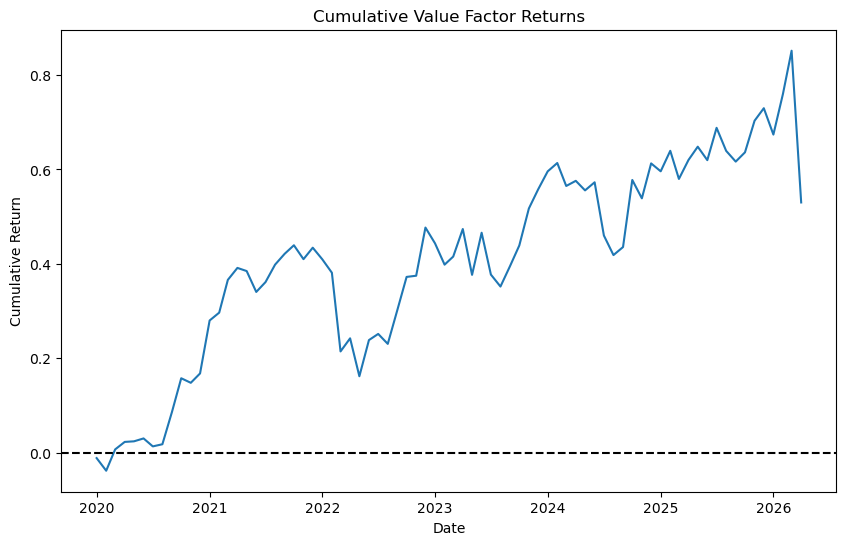

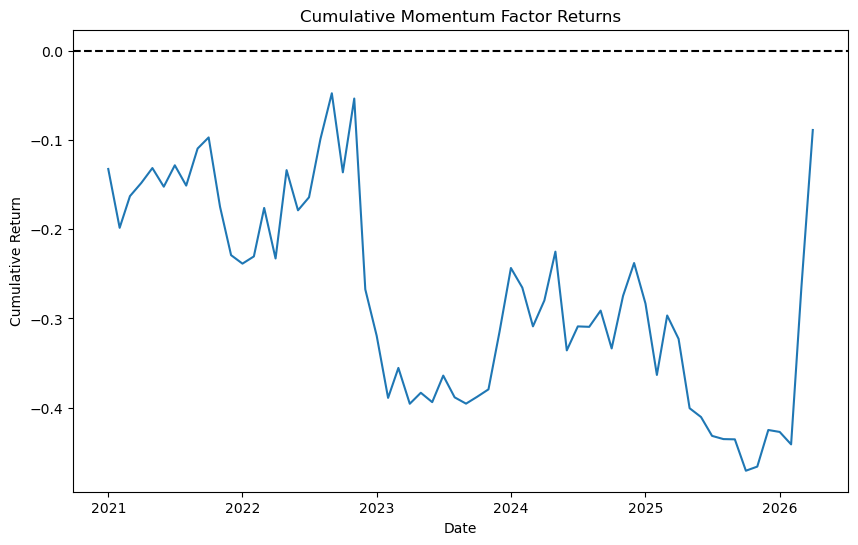

In [18]:
# Now plot the cumulative result (so we can hopefully see indication of our total investment returns over the course of the investment period

def plot_cumulative_returns(
    df,
    cumulative_column,
    title="Cumulative Factor Returns"
):
    """
    This function plots cumulative returns over time.

    Inputs:
        df: dataframe, value_factor_returns or momentum_factor_returns
        cumulative_column: cumulative return column (str)
        title: plot title (str)
    """

    plot_df = df.copy()

    # Convert Period month into timestamp for plotting
    plot_df["date"] = plot_df["month"].dt.to_timestamp()

    plt.figure(figsize=(10, 6))

    plt.plot(
        plot_df["date"],
        plot_df[cumulative_column]
    )

    plt.axhline(
        0,
        linestyle="--",
        color="black"
    )

    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.title(title)

    plt.show()

plot_cumulative_returns(value_factor_returns, "value_cumulative_factor_return", "Cumulative Value Factor Returns")
plot_cumulative_returns(momentum_factor_returns, "momentum_cumulative_factor_return", "Cumulative Momentum Factor Returns")

# Task 5

Here we do further analysis on the portfolio, computing relevant statistics, quintile plots, and correlations.

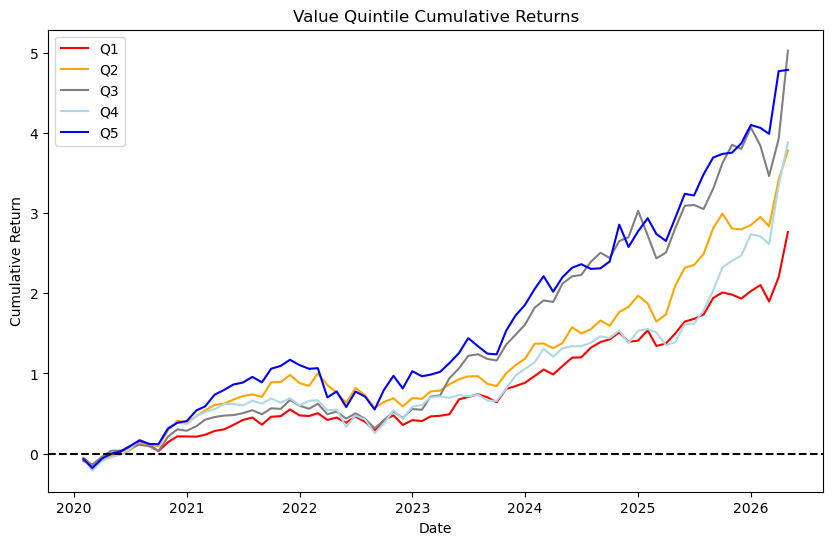

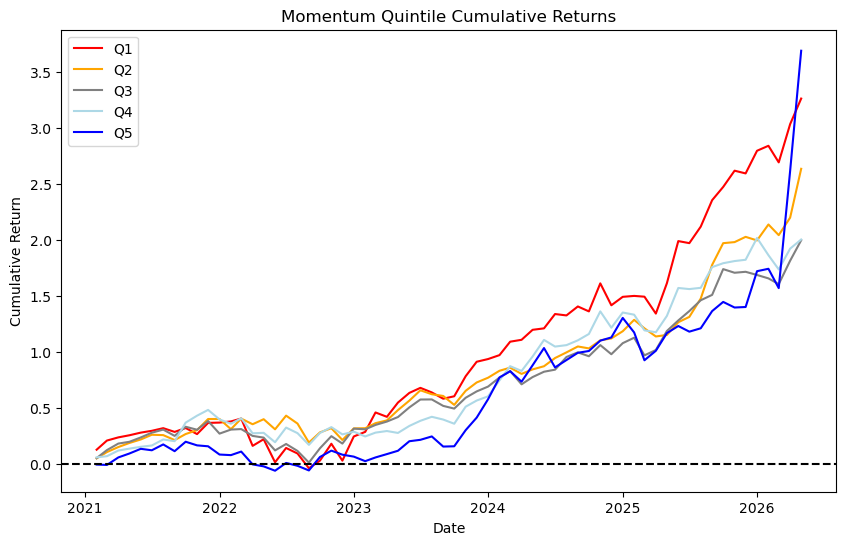

In [19]:
# The above picture provides the total gains/losses from such a portfolio. Now according to our task, we also plot cumulative returns for each quintile:
def plot_quintile_cumulative_returns(
    quintile_df,
    return_column="next_month_return",
    title="Cumulative Returns by Quintile"
):
    """
    Calculate, then plot cumulative returns for Q1-Q5, assuming equal-weight portfolios

    Inputs:
        quintile_df: dataframe containing month, quintile, and next-month returns
        return_column: column containing holding-period returns (str)
        title: plot title (str)

    Output:
        dataframe containing monthly and cumulative returns for each quintile
        plots
    """

    # Average stock return within each quintile each month
    quintile_returns = (
        quintile_df
        .groupby(
            ["month", "quintile"],
            observed=True
        )[return_column]
        .mean()
        .reset_index(name="quintile_return")
    )

    # Sort chronologically
    quintile_returns = quintile_returns.sort_values(
        ["quintile", "month"]
    )

    # Compound returns separately for each quintile
    quintile_returns["cumulative_return"] = (
        quintile_returns
        .groupby(
            "quintile",
            observed=True
        )["quintile_return"]
        .transform(
            lambda x: (1 + x).cumprod() - 1
        )
    )

    # Plot
    plt.figure(figsize=(10, 6))

    colors = {
    1: "red",
    2: "orange",
    3: "gray",
    4: "lightblue",
    5: "blue"
    }

    for q in range(1, 6):

        data = quintile_returns[
            quintile_returns["quintile"] == q
        ]

        plt.plot(
        (data["month"] + 1).dt.to_timestamp(),
        data["cumulative_return"],
        label=f"Q{q}",
        color=colors[q]
        )

    plt.axhline(
        0,
        linestyle="--",
        color="black"
    )

    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.title(title)
    plt.legend()

    plt.show()

    return quintile_returns

value_quintile_returns = plot_quintile_cumulative_returns(
    value_quintiles,
    title="Value Quintile Cumulative Returns"
)

momentum_quintile_returns = plot_quintile_cumulative_returns(
    momentum_quintiles,
    title="Momentum Quintile Cumulative Returns"
)

In [20]:
# Compute statistics for the entire portfolio performance
def factor_statistics(
    df,
    return_column,
    risk_free_rate=0
):
    """
    Compute performance statistics for monthly factor returns.

    Inputs:
        df: dataframe containing monthly factor returns
        return_column: column containing factor returns
        risk_free_rate: annual risk-free rate, default = 0

    Output:
        annualized return
        annualized volatility
        Sharpe ratio
        maximum drawdown
        hit rate
    """

    returns = df[return_column].dropna()

    # Number of months
    n_months = len(returns)

    # Annualized return
    annualized_return = (
        (1 + returns).prod() ** (12 / n_months)
        - 1
    )

    # Annualized volatility
    annualized_volatility = (
        returns.std() * np.sqrt(12)
    )

    # Sharpe ratio
    sharpe_ratio = (
        (annualized_return - risk_free_rate)
        / annualized_volatility
    )

    # Cumulative wealth
    wealth = (1 + returns).cumprod()

    # Previous highest wealth level
    running_peak = wealth.cummax()

    # Drawdown at each point
    drawdown = (
        wealth / running_peak - 1
    )

    # Worst drawdown
    max_drawdown = drawdown.min()

    # Percentage of months where factor return > 0
    hit_rate = (
        (returns > 0).mean()
    )

    return pd.Series({
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown": max_drawdown,
        "Hit Rate": hit_rate
    })

value_stats = factor_statistics(
    value_factor_returns,
    return_column="value_factor_return"
)

momentum_stats = factor_statistics(
    momentum_factor_returns,
    return_column="momentum_factor_return"
)

factor_stats = pd.DataFrame({
    "Value": value_stats,
    "Momentum": momentum_stats
})

display(factor_stats)

,Value,Momentum
Annualized Return,0.069454,-0.017292
Annualized Volatility,0.154286,0.295402
Sharpe Ratio,0.450161,-0.058538
Max Drawdown,-0.192652,-0.444219
Hit Rate,0.618421,0.484375


In [21]:
# Now for the quintiles, though I'm not sure how useful this will be
def quintile_statistics(
    quintile_returns_df,
    risk_free_rate=0
):
    """
    Compute performance statistics separately for each quintile.

    Input:
        quintile_returns_df: dataframe containing
                             month, quintile, quintile_return
        risk_free_rate: annual risk-free rate

    Output:
        dataframe of statistics for Q1-Q5
    """

    results = []

    for q in range(1, 6):

        returns = (
            quintile_returns_df[
                quintile_returns_df["quintile"] == q
            ]["quintile_return"]
            .dropna()
        )

        n_months = len(returns)

        # Annualized return
        annualized_return = (
            (1 + returns).prod() ** (12 / n_months)
            - 1
        )

        # Annualized volatility
        annualized_volatility = (
            returns.std() * np.sqrt(12)
        )

        # Sharpe ratio
        sharpe_ratio = (
            (annualized_return - risk_free_rate)
            / annualized_volatility
        )

        # Wealth over time
        wealth = (1 + returns).cumprod()

        # Running peak
        running_peak = wealth.cummax()

        # Drawdowns
        drawdown = wealth / running_peak - 1

        # Maximum drawdown
        max_drawdown = drawdown.min()

        # Hit rate
        hit_rate = (returns > 0).mean()

        results.append({
            "quintile": f"Q{q}",
            "annualized_return": annualized_return,
            "annualized_volatility": annualized_volatility,
            "sharpe_ratio": sharpe_ratio,
            "max_drawdown": max_drawdown,
            "hit_rate": hit_rate
        })

    return pd.DataFrame(results)

value_quintile_stats = quintile_statistics(
    value_quintile_returns
)

momentum_quintile_stats = quintile_statistics(
    momentum_quintile_returns
)

print("Value Quintile Statistics")
display(value_quintile_stats)
print("\nMomentum Quintile Statistics")
display(momentum_quintile_stats)

Value Quintile Statistics


,quintile,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,hit_rate
0,Q1,0.232931,0.182503,1.276318,-0.169458,0.697368
1,Q2,0.280277,0.195126,1.436389,-0.216231,0.671053
2,Q3,0.327914,0.209513,1.565121,-0.211372,0.657895
3,Q4,0.284559,0.232340,1.224752,-0.257633,0.671053
4,Q5,0.319464,0.231999,1.377008,-0.285775,0.684211



Momentum Quintile Statistics


,quintile,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,hit_rate
0,Q1,0.312256,0.245986,1.269406,-0.315799,0.718750
1,Q2,0.273672,0.165261,1.655996,-0.167881,0.734375
2,Q3,0.228399,0.168844,1.352719,-0.268506,0.687500
3,Q4,0.228916,0.177105,1.292542,-0.210668,0.671875
4,Q5,0.335970,0.285446,1.177000,-0.216116,0.625000


In [22]:
# Next we want to see how well value and momentum correlate. This mainly looks at our factor return results using value vs momentum. So we merge the relevant datasets.
# A caveat is that the momentum factor returns have 1 year less observations, due to the nature of the rolling statistics needed.
factor_comparison = pd.merge(
    value_factor_returns[
        ["month", "value_factor_return"]
    ],
    momentum_factor_returns[
        ["month", "momentum_factor_return"]
    ],
    on="month",
    how="inner"
)

# And using the simple pearson correlation coefficient
correlation = factor_comparison[
    "value_factor_return"
].corr(
    factor_comparison["momentum_factor_return"]
)

print("Value-Momentum Correlation:", correlation) # We get -0.36, which roughly fits our results that the value factor performed well, whereas the momentum factor performed relatively poorly.

Value-Momentum Correlation: -0.3646164481673692
